# Lab 4: Data Quality Assessment, Preprocessing, and PCA on the MPG Dataset


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [2]:
import os
csv_path = "mpg.csv" if os.path.exists("mpg.csv") else "/mnt/data/mpg.csv"
df = pd.read_csv(csv_path)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 3. Data Quality Assessment

### 3.1 Dataset Overview

In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (398, 9)
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


### 3.2 Data Types

In [4]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

### 3.3 Missing Values

In [5]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

### 3.4 Duplicate Rows

In [6]:
df.duplicated().sum()

np.int64(0)

### 3.5 Statistical Summary

In [7]:
df.describe(include="all")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usa,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,249,6
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,NaN,NaN
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,NaN,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,NaN,NaN
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,NaN,NaN
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,NaN,NaN
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,NaN,NaN


## 4. Data Cleaning

### 4.1 Handle Missing Values

In [8]:
# Fill missing values in horsepower with the median
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

# Verify that missing values are removed
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

### 4.2 Drop Non-Numeric Text Column for Numerical Analysis

In [9]:
# Keep the original dataset, but create a working copy without the car name column
df_clean = df.drop(columns=["name"]).copy()
df_clean.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


## 5. Outlier Detection and Removal Using IQR

In [10]:
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df_clean[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df_clean[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print("Number of outliers:", outlier_mask.sum())

df_no_outliers = df_clean.loc[~outlier_mask].copy()
print("Shape after removing outliers:", df_no_outliers.shape)

Number of outliers: 18
Shape after removing outliers: (380, 8)


### 5.1 Boxplots After Cleaning

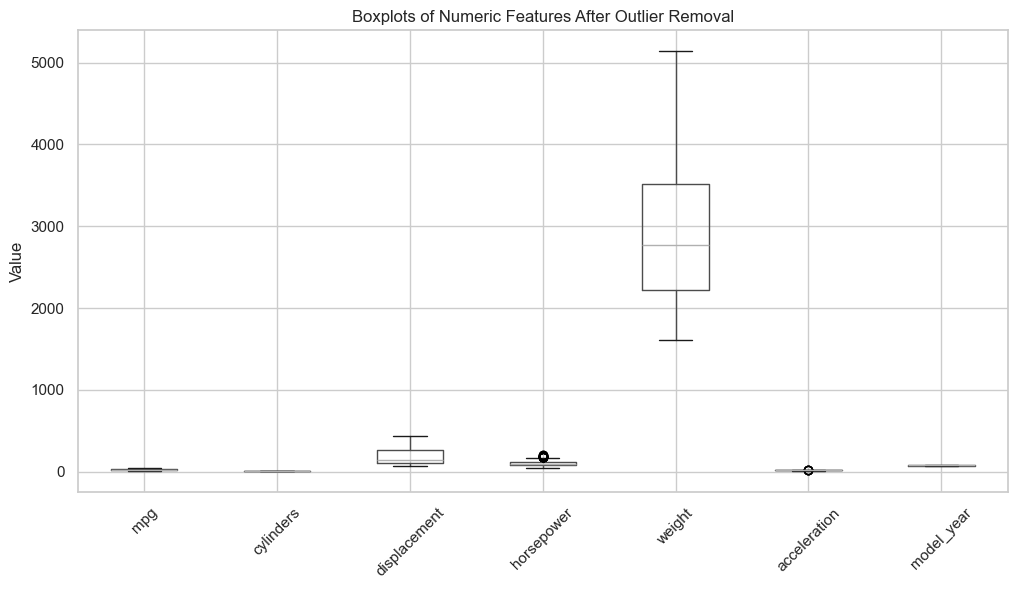

In [11]:
plt.figure(figsize=(12, 6))
df_no_outliers[numeric_cols].boxplot(rot=45)
plt.title("Boxplots of Numeric Features After Outlier Removal")
plt.ylabel("Value")
plt.show()

## 6. Data Transformation

### 6.1 Min-Max Scaling

In [12]:
minmax_scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_no_outliers[numeric_cols]),
    columns=numeric_cols,
    index=df_no_outliers.index
)

df_minmax.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,0.252809,1.0,0.662050,0.552632,0.536150,0.19685,0.0
1,0.168539,1.0,0.781163,0.782895,0.589736,0.15748,0.0
2,0.252809,1.0,0.692521,0.684211,0.516870,0.11811,0.0
3,0.196629,1.0,0.653740,0.684211,0.516019,0.19685,0.0
4,0.224719,1.0,0.648199,0.618421,0.520556,0.07874,0.0


### 6.2 Z-Score Standardization

In [13]:
std_scaler = StandardScaler()

df_zscore_scaled = std_scaler.fit_transform(df_no_outliers[numeric_cols])

df_zscore = pd.DataFrame(
    df_zscore_scaled,
    columns=numeric_cols,
    index=df_no_outliers.index
)

df_zscore.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,-0.760225,1.570442,1.219879,0.869958,0.694716,-1.463981,-1.703135
1,-1.160233,1.570442,1.658633,1.930008,0.924733,-1.665164,-1.703135
2,-0.760225,1.570442,1.332118,1.475701,0.611958,-1.866348,-1.703135
3,-1.026897,1.570442,1.189268,1.475701,0.608307,-1.463981,-1.703135
4,-0.893561,1.570442,1.168861,1.172829,0.627779,-2.067531,-1.703135


## 7. Principal Component Analysis (PCA)

### 7.1 Apply PCA

In [14]:
pca = PCA()
pca_results = pca.fit_transform(df_zscore)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio by Each Principal Component:")
for i, ratio in enumerate(explained_variance, start=1):
    print(f"PC{i}: {ratio*100:.2f}%")

Explained Variance Ratio by Each Principal Component:
PC1: 69.98%
PC2: 13.25%
PC3: 11.22%
PC4: 2.75%
PC5: 1.57%
PC6: 0.81%
PC7: 0.43%


### 7.2 Cumulative Explained Variance

In [15]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.6997812 , 0.83228425, 0.94450863, 0.97197721, 0.98763857,
       0.99570488, 1.        ])

### 7.3 Scree Plot

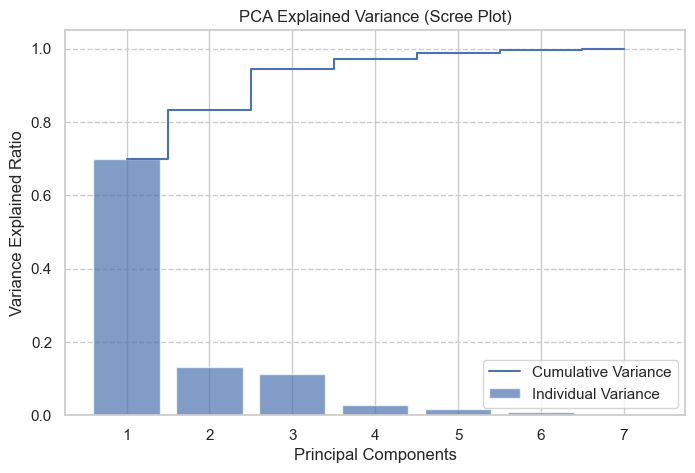

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label="Individual Variance")
plt.step(range(1, len(explained_variance) + 1), cumulative_variance, where="mid", label="Cumulative Variance")

plt.title("PCA Explained Variance (Scree Plot)")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained Ratio")
plt.legend(loc="best")
plt.grid(axis="y", linestyle="--")
plt.show()

### 7.4 Reduce to 2 Principal Components

In [17]:
pca_2 = PCA(n_components=2)
principal_components = pca_2.fit_transform(df_zscore)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"], index=df_zscore.index)
pca_df.head()

,PC1,PC2
0,2.894384,-0.899671
1,3.849687,-0.746680
2,3.273801,-0.769843
3,3.211205,-0.915731
4,3.186442,-0.831377


## 8. PCA Visualization

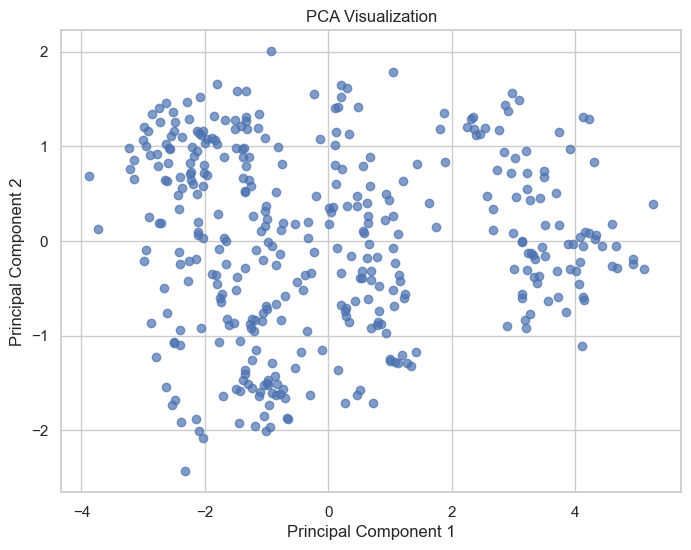

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.grid(True)
plt.show()

## 9. Correlation Heatmap

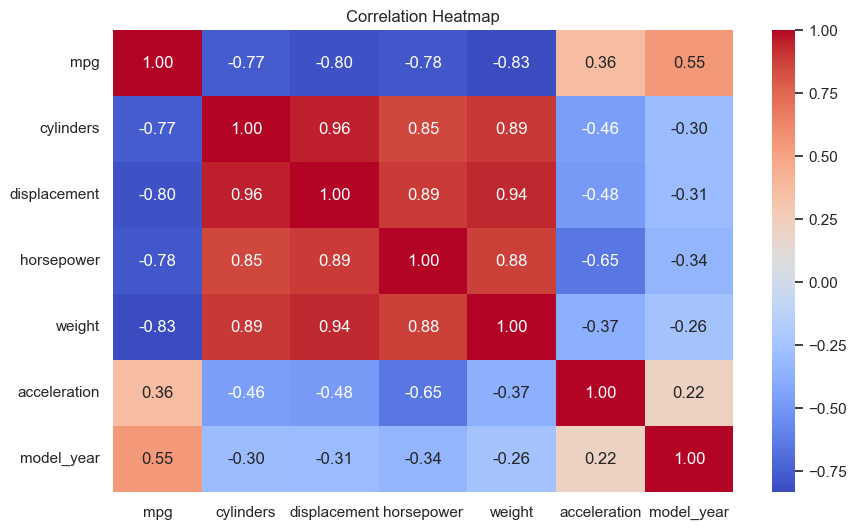

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_no_outliers[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 10. Key Insights

- `mpg` has a strong negative correlation with `weight`, `displacement`, `horsepower`, and `cylinders`, which means fuel efficiency decreases as cars become larger and more powerful.
- `model_year` has a positive relationship with `mpg`, suggesting that newer models in this dataset tend to be more fuel efficient.
- After preprocessing, the first principal component captures most of the dataset variation, and the first two principal components together explain more than 80% of the total variance.
- PCA helps reduce the dataset to two main dimensions while preserving most of the important information.